In [141]:
# Starter code for the Coursera SDC Course 2 final project
# Author: Trevor Ablett and Jonathan Kelly
# University of Toronto Institute for Aerospace Studies
import pickle
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from rotations import angle_normalize, rpy_jacobian_axis_angle, skew_symmetric, Quaternion
#### 1. Data ###################################################################################

################################################################################################
# This is where you will load the data from the pickle files. For parts 1 and 2, you will use
# p1_data.pkl. For Part 3, you will use pt3_data.pkl.
################################################################################################
with open('data/pt3_data.pkl', 'rb') as file:
    data = pickle.load(file)
################################################################################################
# Each element of the data dictionary is stored as an item from the data dictionary, which we
# will store in local variables, described by the following:
#   gt: Data object containing ground truth. with the following fields:
#     a: Acceleration of the vehicle, in the inertial frame
#     v: Velocity of the vehicle, in the inertial frame
#     p: Position of the vehicle, in the inertial frame
#     alpha: Rotational acceleration of the vehicle, in the inertial frame
#     w: Rotational velocity of the vehicle, in the inertial frame
#     r: Rotational position of the vehicle, in Euler (XYZ) angles in the inertial frame
#     _t: Timestamp in ms.
#   imu_f: StampedData object with the imu specific force data (given in vehicle frame).
#     data: The actual data
#     t: Timestamps in ms.
#   imu_w: StampedData object with the imu rotational velocity (given in the vehicle frame).
#     data: The actual data
#     t: Timestamps in ms.
#   gnss: StampedData object with the GNSS data.
#     data: The actual data
#     t: Timestamps in ms.
#   lidar: StampedData object with the LIDAR data (positions only).
#     data: The actual data
#     t: Timestamps in ms.
################################################################################################
gt = data['gt']
imu_f = data['imu_f']
imu_w = data['imu_w']
gnss = data['gnss']
lidar = data['lidar']

/tmp/ipykernel_95920/4181571751.py:16: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  data = pickle.load(file)


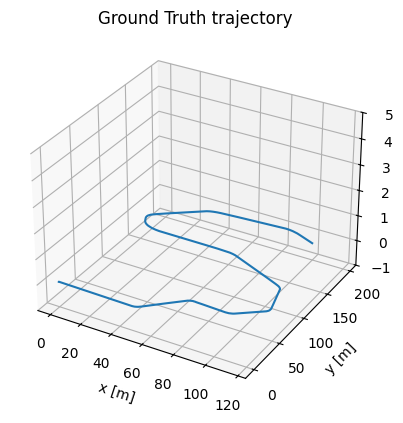

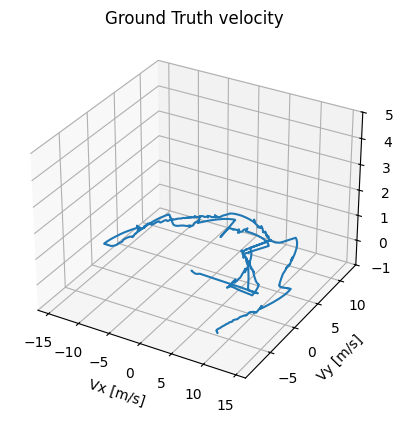

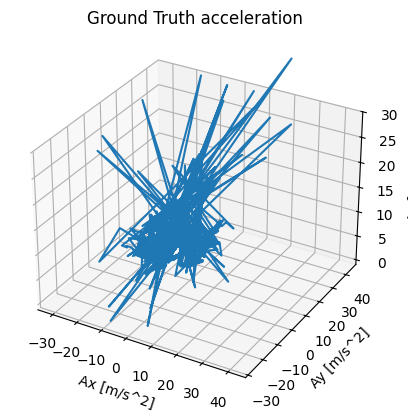

In [142]:
################################################################################################
# Let's plot the ground truth trajectory to see what it looks like. When you're testing your
# code later, feel free to comment this out.
################################################################################################
gt_fig = plt.figure()
ax = gt_fig.add_subplot(111, projection='3d')
ax.plot(gt.p[:,0], gt.p[:,1], gt.p[:,2])
ax.set_xlabel('x [m]')
ax.set_ylabel('y [m]')
ax.set_zlabel('z [m]')
ax.set_title('Ground Truth trajectory')
ax.set_zlim(-1, 5)
plt.show()

# 
gt_fig = plt.figure()
ax = gt_fig.add_subplot(111, projection='3d')
ax.plot(gt.v[:,0], gt.v[:,1], gt.v[:,2])
ax.set_xlabel('Vx [m/s]')
ax.set_ylabel('Vy [m/s]')
ax.set_zlabel('Vz [m/s]')
ax.set_title('Ground Truth velocity')
ax.set_zlim(-1, 5)
plt.show()

gt_fig = plt.figure()
ax = gt_fig.add_subplot(111, projection='3d')
ax.plot(gt.a[:,0], gt.a[:,1], gt.a[:,2])
ax.set_xlabel('Ax [m/s^2]')
ax.set_ylabel('Ay [m/s^2]')
ax.set_zlabel('Az [m/s^2]')
ax.set_title('Ground Truth acceleration')
ax.set_zlim(-1, 30)
plt.show()

In [ ]:
################################################################################################
# Remember that our LIDAR data is actually just a set of positions estimated from a separate
# scan-matching system, so we can insert it into our solver as another position measurement,
# just as we do for GNSS. However, the LIDAR frame is not the same as the frame shared by the
# IMU and the GNSS. To remedy this, we transform the LIDAR data to the IMU frame using our 
# known extrinsic calibration rotation matrix C_li and translation vector t_i_li.
#
# THIS IS THE CODE YOU WILL MODIFY FOR PART 2 OF THE ASSIGNMENT.
################################################################################################
# Correct calibration rotation matrix, corresponding to Euler RPY angles (0.05, 0.05, 0.1).
C_li = np.array([
  [ 0.99376, -0.09722,  0.05466],
   [ 0.09971,  0.99401, -0.04475],
   [-0.04998,  0.04992,  0.9975 ]
 ])

# Incorrect calibration rotation matrix, corresponding to Euler RPY angles (0.05, 0.05, 0.05).
#C_li = np.array([
#      [ 0.9975 , -0.04742,  0.05235],
#      [ 0.04992,  0.99763, -0.04742],
#      [ -0.04998,  0.04992,  0.9975 ]
#])

t_i_li = np.array([0.5, 0.1, 0.5])

# Transform from the LIDAR frame to the vehicle (IMU) frame.
lidar.data = (C_li @ lidar.data.T).T + t_i_li

#### 2. Constants ##############################################################################

################################################################################################
# Now that our data is set up, we can start getting things ready for our solver. One of the
# most important aspects of a filter is setting the estimated sensor variances correctly.
# We set the values here.
################################################################################################
# var_imu_f is the variance of the IMU **specific force** measurements, in m^2/s^4 (in x, y, and z)
var_imu_f = 0.01
# var_imu_w is the variance of the IMU **angular rate** measurements, in rad^2/s^2 (in x, y, and z)
var_imu_w = 0.01 
# var_gnss is the variance of the GNSS **position** measurements, in m^2 (in x, y, and z)
var_gnss  = 10.00
# var_lidar is the variance of the LIDAR **position** measurements, in m^2 (in x, y, and z)
var_lidar = 10.00

Q = np.zeros([6, 6])  # process noise covariance
Q[:3, :3] = np.eye(3) * var_imu_f
Q[3:, 3:] = np.eye(3) * var_imu_w

################################################################################################
# We can also set up some constants that won't change for any iteration of our solver.
################################################################################################
g = np.array([0, 0, -9.81])  # gravity
L_jac = np.zeros([9, 6]) # THIS IS G!
L_jac[3:,:] = np.eye(6) # Motion Model Jacobian that maps IMU noise to velocity and orientation error.
H_jac = np.zeros([3, 9])
H_jac[:, :3] = np.eye(3)  # THIS IS H - Motion model Jac! (for position measurements only)


#### 3. Initial Values #########################################################################

################################################################################################
# Let's set up some initial values for our ES-EKF solver.
################################################################################################
p_est = np.zeros([imu_f.data.shape[0], 3])  # position estimates
v_est = np.zeros([imu_f.data.shape[0], 3])  # velocity estimates
q_est = np.zeros([imu_f.data.shape[0], 4])  # orientation estimates as quaternions
p_cov = np.zeros([imu_f.data.shape[0], 9, 9])  # covariance matrices at each timestep

# Set initial values.
p_est[0] = gt.p[0]
v_est[0] = gt.v[0]
q_est[0] = Quaternion(euler=gt.r[0]).to_numpy()
#p_cov[0] = np.eye(9) * 0.01 # initial covariance. DO NOT SET THIS TO ZERO, OR YOUR FILTER WILL NOT WORK! 
p_cov[0] = np.zeros(9)  # covariance of estimate   
gnss_i  = 0
lidar_i = 0

In [133]:
#### 4. Measurement Update #####################################################################

################################################################################################
# Since we'll need a measurement update for both the GNSS and the LIDAR data, let's make
# a function for it.
################################################################################################
def measurement_update(sensor_var, p_cov_check, y_k, p_check, v_check, q_check):

    # 3.1 Compute Kalman Gain
    R_cov = sensor_var * np.eye(3) 
    S = H_jac @ p_cov_check @ H_jac.T + R_cov

    # Equation for Gain: K = P_check * H^T * (H * P_check * H^T + R)^-1
    K = p_cov_check @ H_jac.T @ np.linalg.inv(S)

    # 3.2 Compute error state
    dx = K @ (y_k - p_check)

    # 3.3 Correct predicted state
    p_check = p_check + dx[:3]
    v_check = v_check + dx[3:6]
    q_check = Quaternion(axis_angle=dx[6:]).quat_mult_right(Quaternion(*q_check))

    # 3.4 Compute corrected covariance
    p_cov_check = (np.eye(9) - K @ H_jac) @ p_cov_check

    return p_check, v_check, q_check, p_cov_check

In [134]:
#### 5. Main Filter Loop #######################################################################

# The process model:
# p_k = p_{k-1} + v_{k-1} * dt + 0.5 * R(q_{k-1}) * f_{k-1} * dt^2
# v_k = dv_{k-1} + (R(q) * df - R(q_{k-1}) * skew[f] * dtheta) * dt
# q_k = q_{k-1} * q(omega_{k-1} * dt)

# For this case, F(9x9), L(9x6)  are:
# F{k-1} = [[I, dt*I, -0.5R*skew[f]*dt^2    ],
#           [0, I   , -R(q_{k-1})*skew[f]*dt],
#           [0, 0   , I - skew[omega]*dt    ]]
#
# L{k-1} =  [0            , 0               ],
#           [R(q_{k-1})*dt, 0               ],
#           [0            , I*dt            ]]

for k in range(1, imu_f.data.shape[0]):
    delta_t = imu_f.t[k] - imu_f.t[k - 1]

    # 1. Nominal state update
    R_sb = Quaternion(*q_est[k-1]).to_mat()
    accel_world = R_sb @ imu_f.data[k-1] + g

    p_est[k] = p_est[k-1] + v_est[k-1] * delta_t + 0.5 * accel_world * delta_t**2
    v_est[k] = v_est[k-1] + accel_world * delta_t

    dq = Quaternion(euler=imu_w.data[k-1] * delta_t)
    q_est[k] = dq.quat_mult_right(q_est[k - 1])

    # 1.1 Jacobians - we'll let go of orientation error terms for this part of the assignment, 
    # since we're only doing position measurements, but you will need to include them for part 2.
    F = np.eye(9)
    imu = imu_f.data[k - 1].reshape((3, 1)) # just to make the math work out for the next few lines
    F[:3, 3:6]  = np.eye(3) * delta_t
    F[:3, 6:9]  = -0.5 * R_sb @ skew_symmetric(imu_f.data[k-1]) * delta_t**2
    F[3:6, 6:9] = -R_sb @ skew_symmetric(imu) * delta_t
    F[6:9, 6:9] = np.eye(3) - skew_symmetric(imu_w.data[k-1]) * delta_t

    L_jac[0:3, 0:3] = 0.5 * R_sb * delta_t**2
    L_jac[3:6, 0:3] = R_sb * delta_t
    L_jac[6:9, 3:6] = np.eye(3) * delta_t

    # 2. Propagate uncertainty
    p_cov[k] = F @ p_cov[k-1] @ F.T + L_jac @ Q @ L_jac.T

    # 3. Measurement updates
    while gnss_i < gnss.data.shape[0] and gnss.t[gnss_i] <= imu_f.t[k]:
        p_est[k], v_est[k], q_est[k], p_cov[k] = measurement_update(var_gnss, p_cov[k], gnss.data[gnss_i] , p_est[k], v_est[k], q_est[k])
        q_est[k] /= np.linalg.norm(q_est[k])
        gnss_i += 1

    while lidar_i < lidar.t.shape[0] and imu_f.t[k] >= lidar.t[lidar_i]:
        # lidar.data is already in IMU frame (transformed once at top of notebook)
        p_est[k], v_est[k], q_est[k], p_cov[k] = measurement_update(var_lidar, p_cov[k], lidar.data[lidar_i], p_est[k], v_est[k], q_est[k])
        q_est[k] /= np.linalg.norm(q_est[k])
        lidar_i += 1

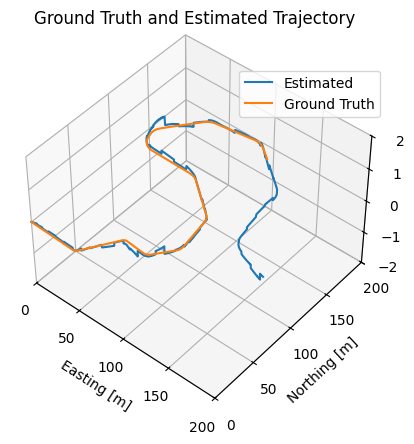

In [135]:
#### 6. Results and Analysis ###################################################################

################################################################################################
# Now that we have state estimates for all of our sensor data, let's plot the results. This plot
# will show the ground truth and the estimated trajectories on the same plot. Notice that the
# estimated trajectory continues past the ground truth. This is because we will be evaluating
# your estimated poses from the part of the trajectory where you don't have ground truth!
################################################################################################
est_traj_fig = plt.figure()
ax = est_traj_fig.add_subplot(111, projection='3d')
ax.plot(p_est[:,0], p_est[:,1], p_est[:,2], label='Estimated')
ax.plot(gt.p[:,0], gt.p[:,1], gt.p[:,2], label='Ground Truth')
ax.set_xlabel('Easting [m]')
ax.set_ylabel('Northing [m]')
ax.set_zlabel('Up [m]')
ax.set_title('Ground Truth and Estimated Trajectory')
ax.set_xlim(0, 200)
ax.set_ylim(0, 200)
ax.set_zlim(-2, 2)
ax.set_xticks([0, 50, 100, 150, 200])
ax.set_yticks([0, 50, 100, 150, 200])
ax.set_zticks([-2, -1, 0, 1, 2])
ax.legend(loc=(0.62,0.77))
ax.view_init(elev=45, azim=-50)
plt.show()

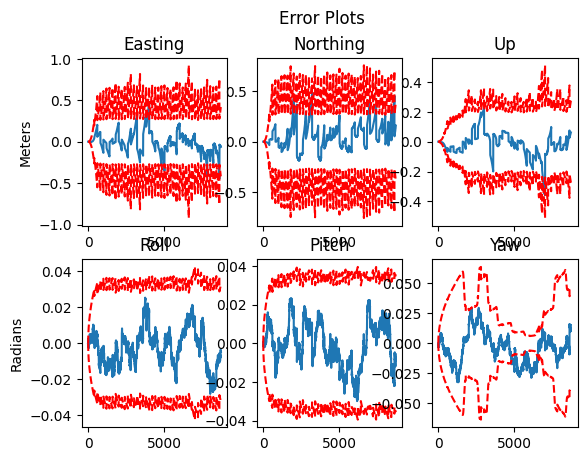

In [136]:
################################################################################################
# We can also plot the error for each of the 6 DOF, with estimates for our uncertainty
# included. The error estimates are in blue, and the uncertainty bounds are red and dashed.
# The uncertainty bounds are +/- 3 standard deviations based on our uncertainty (covariance).
################################################################################################
error_fig, ax = plt.subplots(2, 3)
error_fig.suptitle('Error Plots')
num_gt = gt.p.shape[0]
p_est_euler = []
p_cov_euler_std = []

# Convert estimated quaternions to euler angles
for i in range(len(q_est)):
    qc = Quaternion(*q_est[i, :])
    p_est_euler.append(qc.to_euler())

    # First-order approximation of RPY covariance
    J = rpy_jacobian_axis_angle(qc.to_axis_angle())
    p_cov_euler_std.append(np.sqrt(np.diagonal(J @ p_cov[i, 6:, 6:] @ J.T)))

p_est_euler = np.array(p_est_euler)
p_cov_euler_std = np.array(p_cov_euler_std)

# Get uncertainty estimates from P matrix
p_cov_std = np.sqrt(np.diagonal(p_cov[:, :6, :6], axis1=1, axis2=2))

titles = ['Easting', 'Northing', 'Up', 'Roll', 'Pitch', 'Yaw']
for i in range(3):
    ax[0, i].plot(range(num_gt), gt.p[:, i] - p_est[:num_gt, i])
    ax[0, i].plot(range(num_gt),  3 * p_cov_std[:num_gt, i], 'r--')
    ax[0, i].plot(range(num_gt), -3 * p_cov_std[:num_gt, i], 'r--')
    ax[0, i].set_title(titles[i])
ax[0,0].set_ylabel('Meters')

for i in range(3):
    ax[1, i].plot(range(num_gt), \
        angle_normalize(gt.r[:, i] - p_est_euler[:num_gt, i]))
    ax[1, i].plot(range(num_gt),  3 * p_cov_euler_std[:num_gt, i], 'r--')
    ax[1, i].plot(range(num_gt), -3 * p_cov_euler_std[:num_gt, i], 'r--')
    ax[1, i].set_title(titles[i+3])
ax[1,0].set_ylabel('Radians')
plt.show()



In [137]:
print(f"GNSS ends at t={gnss.t[-1]:.2f}, IMU ends at t={imu_f.t[-1]:.2f}")
print(f"LIDAR ends at t={lidar.t[-1]:.2f}")

GNSS ends at t=56.32, IMU ends at t=56.65
LIDAR ends at t=56.55


In [ ]:
#### 7. Submission #############################################################################

################################################################################################
# Now we can prepare your results for submission to the Coursera platform. Uncomment the
# corresponding lines to prepare a file that will save your position estimates in a format
# that corresponds to what we're expecting on Coursera.
################################################################################################

# Pt. 1 submission

p1_indices = [9000, 9400, 9800, 10200, 10600]
p1_str = ''
for val in p1_indices:
    for i in range(3):
        p1_str += '%.3f ' % (p_est[val, i])
with open('pt1_submission.txt', 'w') as file:
    file.write(p1_str)


In [ ]:
# Pt. 2 submission
p2_indices = [9000, 9400, 9800, 10200, 10600]
p2_str = ''
for val in p2_indices:
    for i in range(3):
       p2_str += '%.3f ' % (p_est[val, i])
with open('pt2_submission.txt', 'w') as file:
    file.write(p2_str)

In [ ]:
# Pt. 3 submission
p3_indices = [6800, 7600, 8400, 9200, 10000]
p3_str = ''
for val in p3_indices:
    for i in range(3):
        p3_str += '%.3f ' % (p_est[val, i])
with open('pt3_submission.txt', 'w') as file:
    file.write(p3_str)